**1. Suppose we collect data for a group of applicants to a data science bootcamp with variables:**

• X1 = coding practice hours completed,

• X2 = prior programming experience (in years), and

• Y = admitted to the bootcamp.

We fit a logistic regression and produce estimated coefficients

β0 = −4.2, β1 = 0.04, and β2 = 0.8

**(a) Estimate the probability that an applicant who has completed 60 hours of coding practice and has 2 years of programming experience is admitted to the bootcamp**

In [100]:
import numpy as np

#formula with values inputted
#y = (-4.2) + 60(0.04) + 2(0.8)

#value calculated
y = -0.2

sigmoid = lambda z: 1/(1 + np.exp(-y))

#compute probability using sigmoid transformation
p = sigmoid(y)

print(f'probability = {p:.3f}')



probability = 0.450


**(b) How many practice hours would the applicant in part (a) need to study to have a 90% chance of being admitted?**

In [101]:
target = 0.90

#calculate corresponding inverse of sigmoid
logit = np.log(target/(1 - target))

#rearrange equation to solve for x needed
x_needed = (logit - (-4.2) - (0.8)*2)/(0.04)

print(f'Hours needed for 90% chance of admittance = {x_needed:.2f}')

Hours needed for 90% chance of admittance = 119.93


**(c) Describe in words the meaning of “β0 = −4.2” in the context of this model.**

β0 = −4.2 represents the model's intercept, so when a person has no years of programming experience and no practice hours coding, their admission probability is: $e^{-4.2}/(1+e^{-4.2})$ = 0.0148 = 1.48%

**2. As a first step, create two subsets of this data:**

• Train, containing only records with StoreID 1, 2, 3, or 4,

and

• Test, containing remaining records with StoreID 7

We will use these subsets to predict Citrus Hill purchases.

In [102]:
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from ISLP import load_data

#load dataset
OJ = load_data('OJ')

#define specified data fro training + testing set
train_values = [1, 2, 3, 4]
Train = OJ[OJ['StoreID'].isin(train_values)]


test_values = [7]
Test = OJ[OJ['StoreID'].isin(test_values)]



**(a) In Train, locate three variables: Citrus Hill loyalty, indication of a Citrus Hill special, and price difference between the brands Calculate the mean, standard deviation, median, minimum value, and maximum value for each of these variables.**

In [103]:
#compute statistics for each specified variable

#loyalty to Citrus Hill
loyalty = Train['LoyalCH']
loy_mean = loyalty.mean()
loy_median = loyalty.median()
loy_min = loyalty.min()
loy_max = loyalty.max()
loy_sd = loyalty.std()

print('Citrus Hill loyalty stats:')
print(f'Mean: {loy_mean}') 
print(f'Standard Deviation: {loy_sd}')
print(f'Median: {loy_median}')
print(f'Min: {loy_min}')
print(f'Max: {loy_max}')

#specials on Citrus Hill
special = Train['SpecialCH']
spec_mean = special.mean()
spec_median = special.median()
spec_min = special.min()
spec_max = special.max()
spec_sd = special.std()

print('\nCitrus Hill special stats:')
print(f'Mean: {spec_mean}') 
print(f'Standard Deviation: {spec_sd}')
print(f'Median: {spec_median}')
print(f'Min: {spec_min}')
print(f'Max: {spec_max}')

#price difference
price_dif = Train['PriceDiff']
dif_mean = price_dif.mean()
dif_median = price_dif.median()
dif_min = price_dif.min()
dif_max = price_dif.max()
dif_sd = price_dif.std()

print('\nPrice Difference stats:')
print(f'Mean: {dif_mean}') 
print(f'Standard Deviation: {dif_sd}')
print(f'Median: {dif_median}')
print(f'Min: {dif_min}')
print(f'Max: {dif_max}')

Citrus Hill loyalty stats:
Mean: 0.5199879019607843
Standard Deviation: 0.3137571564198037
Median: 0.5
Min: 1.1e-05
Max: 0.999947

Citrus Hill special stats:
Mean: 0.046218487394957986
Standard Deviation: 0.2101051293520389
Median: 0.0
Min: 0
Max: 1

Price Difference stats:
Mean: 0.11452380952380951
Standard Deviation: 0.2559351252805437
Median: 0.2
Min: -0.67
Max: 0.44


**(b) Provide a correlation matrix for the three variables in (a).**

In [104]:
#set selecteted columns to variable
corr_vars = Train[['LoyalCH', 'SpecialCH', 'PriceDiff']]

#generate correlation matrix
corr_vars.corr().style.background_gradient(cmap='coolwarm')

,LoyalCH,SpecialCH,PriceDiff
LoyalCH,1.000000,0.014230,0.008349
SpecialCH,0.014230,1.000000,-0.025542
PriceDiff,0.008349,-0.025542,1.000000


**(c) Use the Train subset to perform a logistic regression with Purchase as the response and the three variables from (a) as predictors. Use the summary function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones?**

In [105]:
#add intercept
X_full = sm.add_constant(corr_vars)

#set target variable
y_train = (Train["Purchase"]=="CH").astype(int)

#fit logistic regression model
model_full = sm.Logit(y_train, X_full).fit()

print("Logistic Regression Summary:")
print(model_full.summary())

#identify statistically significant predictors
sig_predictors = list(model_full.pvalues[model_full.pvalues < 0.05].index)

#remove constant if included
if "const" in sig_predictors:
    sig_predictors.remove("const")

print("Significant predictors:", sig_predictors)

Optimization terminated successfully.
         Current function value: 0.414155
         Iterations 7
Logistic Regression Summary:
                           Logit Regression Results                           
Dep. Variable:               Purchase   No. Observations:                  714
Model:                          Logit   Df Residuals:                      710
Method:                           MLE   Df Model:                            3
Date:                Wed, 22 Oct 2025   Pseudo R-squ.:                  0.4009
Time:                        20:26:52   Log-Likelihood:                -295.71
converged:                       True   LL-Null:                       -493.55
Covariance Type:            nonrobust   LLR p-value:                 1.902e-85
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.4069      0.267    -12.756      0.000      -3.930      -2.883


**(d) Using Train and a probability threshold of 0.5, compute the confusion matrix and overall fraction of correct predictions. Also note the percent of false positives and the percent of false negatives.**

In [106]:
#compute predicted probabilities + class labels for training data
probs_train = model_full.predict(X_full)
preds_train = (probs_train >= 0.5).astype(int)

#generate confusion matrix for training predictions
cm_train = confusion_matrix(y_train, preds_train, labels=[0,1])
tn, fp, fn, tp = cm_train.ravel()

#calculate performance metrics
acc = (tn+tp)/cm_train.sum()
fp_rate = fp/(fp+tn)
fn_rate = fn/(fn+tp)

#display training performance
print("Train Confusion Matrix:")
print(cm_train)
print("Accuracy:", round(acc,4),
     "\nFalse Positive %:", round(fp_rate,4),
     "\nFalse Negative %:", round(fn_rate,4)
     )

Train Confusion Matrix:
[[269  66]
 [ 62 317]]
Accuracy: 0.8207 
False Positive %: 0.197 
False Negative %: 0.1636


**(e) Now refit the logistic regression model on the Train data with only the significant predictors. For this model, use Test to compute the confusion matrix, fraction of correct predictions, percent of false positives, and percent of false negatives.**

In [107]:
#fit logistic regression model only using significant predictors
X_train_sig = sm.add_constant(Train[sig_predictors])
logit_sig = sm.Logit(y_train, X_train_sig).fit(disp=False)

#prepare test data
X_test_sig = sm.add_constant(Test[sig_predictors])
y_test = (Test["Purchase"]=="CH").astype(int)

#make predictions on test set
probs_test_logit = logit_sig.predict(X_test_sig)
preds_test_logit = (probs_test_logit >= 0.5).astype(int)

#evaluate test performance
cm_e = confusion_matrix(y_test, preds_test_logit, labels=[0,1])
tn, fp, fn, tp = cm_e.ravel()

acc = (tn+tp)/cm_e.sum()
fp_rate = fp/(fp+tn)
fn_rate = fn/(fn+tp)

#display results
print("Test Confusion (Logit, sig only):")
print(cm_e)
print("Accuracy:", round(acc,4),
     "\nFalse Positive %:", round(fp_rate,4),
     "\nFalse Negative %:", round(fn_rate,4)
     )

Test Confusion (Logit, sig only):
[[ 60  22]
 [ 34 240]]
Accuracy: 0.8427 
False Positive %: 0.2683 
False Negative %: 0.1241


**(f) Use Naive Bayes on the Train data with only the significant predictors from (e). Use Test to compute the confusion matrix, fraction of correct predictions, percent of false positives, and percent of false negatives.**

In [108]:
#fit Naive Bayes using significant predictors
nb = GaussianNB()
nb.fit(Train[sig_predictors], y_train)

#predict probabilities & binary outcoms for test set
probs_nb = nb.predict_proba(Test[sig_predictors])[:,1]
preds_nb = (probs_nb >= 0.5).astype(int)

#compute confusion matrix for Naive Bayes predictions
cm_f = confusion_matrix(y_test, preds_nb, labels=[0,1])
tn, fp, fn, tp = cm_f.ravel()

#calculate metrics
acc = (tn+tp)/cm_f.sum()
fp_rate = fp/(fp+tn)
fn_rate = fn/(fn+tp)

print("Test Confusion (Naive Bayes):")
print(cm_f)
print("Accuracy:", round(acc,4),
     "\nFalse Positive %:", round(fp_rate,4),
     "\nFalse Negative %:", round(fn_rate,4)
     )

Test Confusion (Naive Bayes):
[[ 64  18]
 [ 39 235]]
Accuracy: 0.8399 
False Positive %: 0.2195 
False Negative %: 0.1423


**(g) Build three k-Nearest Neighbors models on the Train data, using k = 5, 50, 150, and only the significant predictors from (e). For the k = 50 model, use Test to compute the confusion matrix, fraction of correct predictions, percent of false positives, and percent of false negatives.**

In [109]:
def knn_probs(k):
   knn = KNeighborsClassifier(n_neighbors=k)

   #fit model on training set using significant predictors
   knn.fit(Train[sig_predictors], y_train)
   return knn.predict_proba(Test[sig_predictors])[:,1]

#probability when k = 50
probs_knn50 = knn_probs(50)

#probability -> binary predictions using threshold = 0.5
preds_knn50 = (probs_knn50 >= 0.5).astype(int)

#compute confusion matrix
cm_g = confusion_matrix(y_test, preds_knn50, labels=[0,1])

#extract confusion matrix elements
tn, fp, fn, tp = cm_g.ravel()

#compute accuracy, false positive rate, and false negative rate
acc = (tn+tp)/cm_g.sum()
fp_rate = fp/(fp+tn)
fn_rate = fn/(fn+tp)

print("Test Confusion (kNN, k=50):")
print(cm_g)
print("Accuracy:", round(acc,4),
     "\nFalse Positive %:", round(fp_rate,4),
     "\nFalse Negative %:", round(fn_rate,4)
     )

Test Confusion (kNN, k=50):
[[ 62  20]
 [ 40 234]]
Accuracy: 0.8315 
False Positive %: 0.2439 
False Negative %: 0.146


**(h) Provide a ROC curve for each of the five models in parts (e), (f), and (g) on the same plot. Which model yields the highest AUC?**

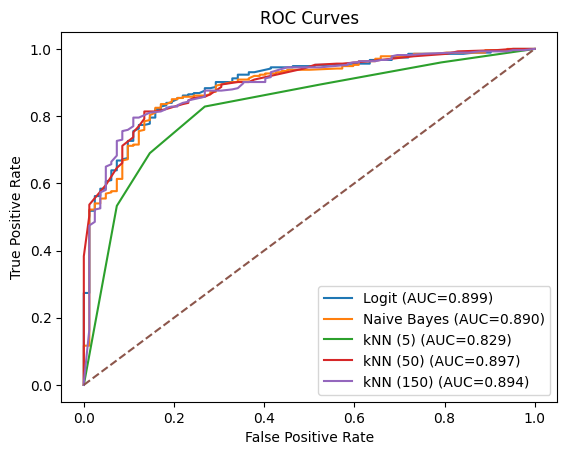

Highest AUC model: Logit | AUC = 0.8985


In [110]:
#compare model performance using ROC curves and AUC
models = {
   "Logit": probs_test_logit,
   "Naive Bayes": probs_nb,
   "kNN (5)": knn_probs(5),
   "kNN (50)": probs_knn50,
   "kNN (150)": knn_probs(150)
}

plt.figure()
best_model, best_auc = None, -1

#compute ROC and AUC
for name, probs in models.items():
   fpr, tpr, _ = roc_curve(y_test, probs)
   A = auc(fpr,tpr)
   plt.plot(fpr, tpr, label=f"{name} (AUC={A:.3f})")

   #track highest AUC
   if A > best_auc:
       best_auc = A
       best_model = name

#plot random classifier refrence line
plt.plot([0,1],[0,1],'--')

plt.legend()
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("Highest AUC model:", best_model, "| AUC =", round(best_auc,4))

**3. In this problem, you will perform K-means clustering manually, with K = 2, on a small example with n = 6 observations and p = 2 features.**

In [111]:
# Data
points = np.array([
   [1,4],
   [1,3],
   [0,4],
   [5,1],
   [6,2],
   [4,0]
])

**(a) Plot the observations using a single color for all data points.**

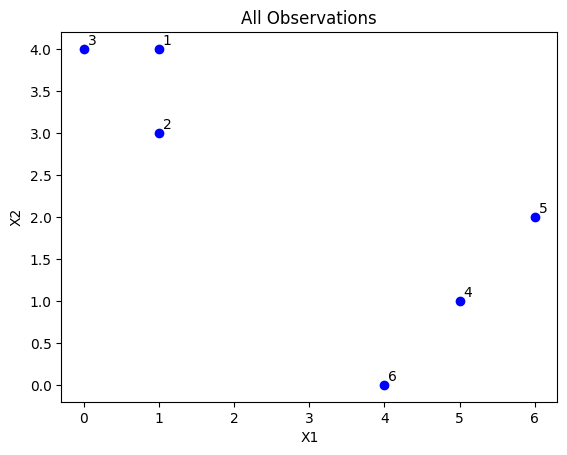

In [112]:
plt.figure()

#scatterplot of points
plt.scatter(points[:,0], points[:,1], color='blue')

#add labels for points
for i, (x,y) in enumerate(points, start=1):
   plt.text(x + 0.05, y + 0.05, str(i))

plt.title("All Observations")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

**(b) Randomly assign a cluster label to each observation. You can use the np.random.choice() function to do this. Report the cluster labels for each observation.**

In [113]:
#randomly assign initial cluster labels
rng = np.random.default_rng(42)
labels = rng.choice([0,1], size=len(points))
print("Initial random labels:", labels)

#comput centroids for each label
def compute_centroids(pts, labels):
    cents = []
    for c in [0,1]:
        cents.append(pts[labels == c].mean(axis=0))
    return np.array(cents)

#assign each point to nearest centroid
def assign_to_nearest(pts, cents):
    new = []
    for p in pts:
        dists = np.linalg.norm(p - cents, axis=1) 
        new.append(np.argmin(dists))
    return np.array(new)

Initial random labels: [0 1 1 0 0 1]


**(c) Compute the centroid for each cluster.**

In [114]:
#compute initial centroids
centroids = compute_centroids(points, labels)
print("Initial centroids:")
print(centroids)

Initial centroids:
[[4.         2.33333333]
 [1.66666667 2.33333333]]


**(d) Assign each observation to the centroid to which it is closest, in terms of Euclidean distance. Report the cluster labels for each observation.**

In [115]:
#reassign labels based on distance to initial centroids
new_labels = assign_to_nearest(points, centroids)

print("Reassigned labels (based on initial centroids):")
for i, label in enumerate(new_labels, start=1):
    print(f"Observation {i} → cluster {label}")

Reassigned labels (based on initial centroids):
Observation 1 → cluster 1
Observation 2 → cluster 1
Observation 3 → cluster 1
Observation 4 → cluster 0
Observation 5 → cluster 0
Observation 6 → cluster 0


**(e) Repeat (c) and (d) until the answers obtained stop changing.**

In [116]:
#keep updating centroids and cluster assignments till convergence
labels = new_labels 

while True:
    centroids = compute_centroids(points, labels)
    updated = assign_to_nearest(points, centroids)

    #stop when labels no longer change
    if np.array_equal(updated, labels):
        break

    labels = updated

print("FINAL stable cluster assignments:")
print(labels)

print("Final centroids:")
print(centroids)

FINAL stable cluster assignments:
[1 1 1 0 0 0]
Final centroids:
[[5.         1.        ]
 [0.66666667 3.66666667]]


**(f) In your plot from (a), color the observations according to the cluster labels obtained.**

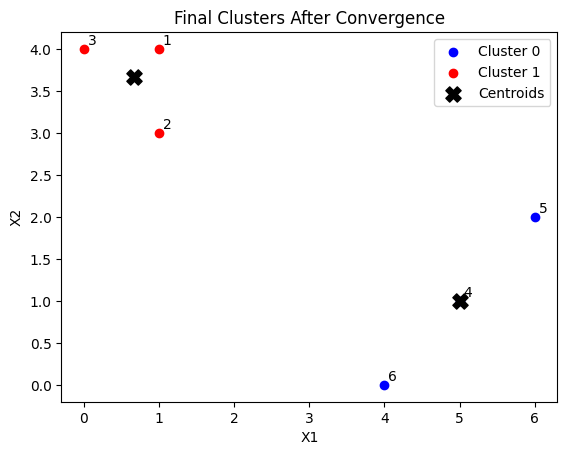

In [117]:
plt.figure()

#plot points by cluster label
plt.scatter(points[labels==0,0], points[labels==0,1], color='blue', label="Cluster 0")
plt.scatter(points[labels==1,0], points[labels==1,1], color='red',  label="Cluster 1")

#label each point w/ index
for i,(x,y) in enumerate(points, start=1):
    plt.text(x + 0.05, y + 0.05, str(i))

#plot centroid locations
plt.scatter(centroids[:,0], centroids[:,1], color='black', marker='X', s=120, label="Centroids")

plt.title("Final Clusters After Convergence")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

**4.**

In [118]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cev = pd.read_csv('../data/CEV2021.csv')

label_col = cev.columns[0]
numeric = cev.select_dtypes(include=[np.number]).copy()

#keep only rows with complete data
mask_complete = numeric.dropna(axis=0, how='any').index
numeric = numeric.loc[mask_complete].reset_index(drop=True)
labels = cev.loc[mask_complete, label_col].astype(str).reset_index(drop=True)

**(a) Using hierarchical clustering with complete linkage and Euclidean distance, cluster the states. Report your answer with a dendrogram.**

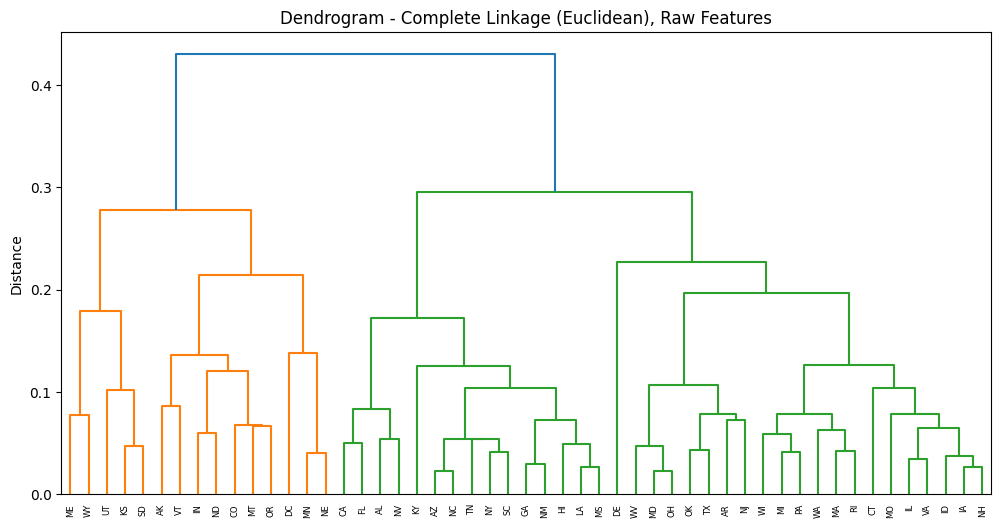

In [ ]:
Z = linkage(numeric.values, method='complete', metric='euclidean')

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=labels.values, leaf_rotation=90)

plt.title("Dendrogram - Complete Linkage (Euclidean), Raw Features")
plt.ylabel("Distance")
plt.show()

**(b) Cut the dendrogram at a height that results in three distinct clusters. Which states belong to which clusters?**

In [ ]:
clusters3 = fcluster(Z, t=3, criterion='maxclust')
df3 = pd.DataFrame({label_col: labels, "Cluster3": clusters3})

for c in sorted(df3["Cluster3"].unique()):
    print(f"Cluster {c}:")
    print(df3.loc[df3["Cluster3"] == c, label_col].tolist())

Cluster 1:
['AK', 'CO', 'DC', 'IN', 'KS', 'ME', 'MN', 'MT', 'NE', 'ND', 'OR', 'SD', 'UT', 'VT', 'WY']
Cluster 2:
['AL', 'AZ', 'CA', 'FL', 'GA', 'HI', 'KY', 'LA', 'MS', 'NV', 'NM', 'NY', 'NC', 'SC', 'TN']
Cluster 3:
['AR', 'CT', 'DE', 'ID', 'IL', 'IA', 'MD', 'MA', 'MI', 'MO', 'NH', 'NJ', 'OH', 'OK', 'PA', 'RI', 'TX', 'VA', 'WA', 'WV', 'WI']


**(c) Cut the dendrogram at a height that results in four distinct clusters. Which states belong to which clusters?**

In [134]:
#cut dendrogram to form 4 clusters
clusters4 = fcluster(Z, t=4, criterion='maxclust')

#create dataframe with state labels and cluster assignment
df4 = pd.DataFrame({label_col: labels, "Cluster4": clusters4})

for c in sorted(df4["Cluster4"].unique()):
    print(f"Cluster {c}:")
    print(df4.loc[df4["Cluster4"] == c, label_col].tolist())

Cluster 1:
['KS', 'ME', 'SD', 'UT', 'WY']
Cluster 2:
['AK', 'CO', 'DC', 'IN', 'MN', 'MT', 'NE', 'ND', 'OR', 'VT']
Cluster 3:
['AL', 'AZ', 'CA', 'FL', 'GA', 'HI', 'KY', 'LA', 'MS', 'NV', 'NM', 'NY', 'NC', 'SC', 'TN']
Cluster 4:
['AR', 'CT', 'DE', 'ID', 'IL', 'IA', 'MD', 'MA', 'MI', 'MO', 'NH', 'NJ', 'OH', 'OK', 'PA', 'RI', 'TX', 'VA', 'WA', 'WV', 'WI']


**(d) Use K-means clustering and K = 3 to obtain new clusters of states. Which states belong to which clusters?**

In [ ]:
k3 = KMeans(n_clusters=3, n_init=25, random_state=0)

#fit KMeans to data and get cluster labels
k_labels_raw = k3.fit_predict(numeric.values)

#create dataframe combining state labels and cluster assignment
df_k3 = pd.DataFrame({label_col: labels, "KMeans3": k_labels_raw})

for c in sorted(df_k3["KMeans3"].unique()):
    print(f"Cluster {c}:")
    print(df_k3.loc[df_k3["KMeans3"] == c, label_col].tolist())

Cluster 0:
['AK', 'CO', 'DC', 'ME', 'MN', 'MT', 'NE', 'ND', 'OR', 'VT', 'WY']
Cluster 1:
['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'HI', 'KY', 'LA', 'MD', 'MS', 'NV', 'NJ', 'NM', 'NY', 'NC', 'OH', 'OK', 'SC', 'TN', 'TX', 'WV']
Cluster 2:
['CT', 'DE', 'ID', 'IL', 'IN', 'IA', 'KS', 'MA', 'MI', 'MO', 'NH', 'PA', 'RI', 'SD', 'UT', 'VA', 'WA', 'WI']


**(e) Repeat part (a), but first rescale and replace your variables so that they have mean 0 and standard deviation 1 (i.e., perform the clustering on the z-scores of the features, rather than the features themselves). Provide the new dendrogram.**

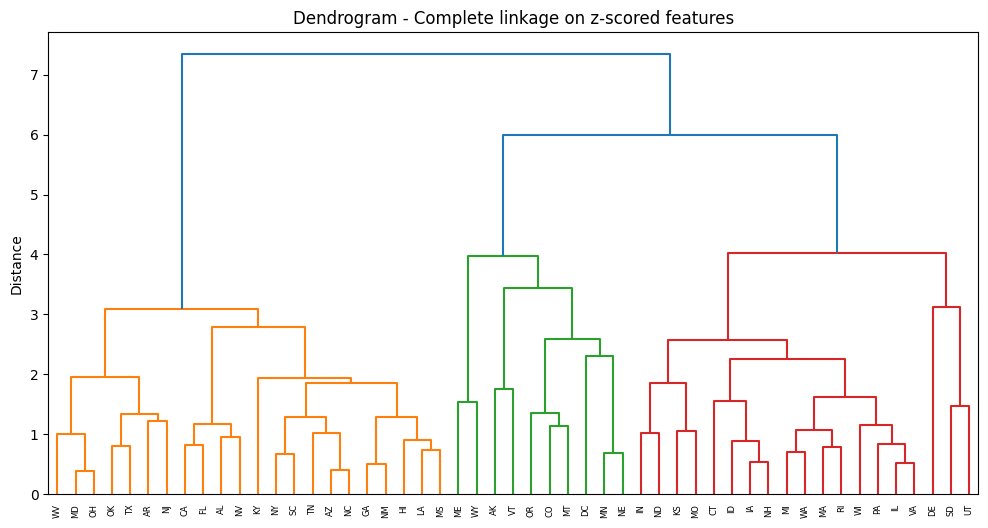

In [137]:
scaler = StandardScaler()
numeric_z = scaler.fit_transform(numeric.values)

#hierachical clustering on z-scored data
Zz = linkage(numeric_z, method='complete', metric='euclidean')

plt.figure(figsize=(12, 6))
dendrogram(Zz, labels=labels.values, leaf_rotation=90)
plt.title("Dendrogram - Complete linkage on z-scored features")
plt.ylabel("Distance")
plt.show()

**(f) Cut the new dendrogram from part (e) at a height that results in three distinct clusters. Which states belong to which clusters?**

In [139]:
#cut dendrogram of z-scored data into 3 clusters
clusters3_z = fcluster(Zz, t=3, criterion='maxclust')

#create dataframe with state labels and cluster assignments
df3z = pd.DataFrame({label_col: labels, "Cluster3_Z": clusters3_z})

for c in sorted(df3z["Cluster3_Z"].unique()):
    print(f"Cluster {c}:")
    print(df3z.loc[df3z["Cluster3_Z"] == c, label_col].tolist())

Cluster 1:
['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'HI', 'KY', 'LA', 'MD', 'MS', 'NV', 'NJ', 'NM', 'NY', 'NC', 'OH', 'OK', 'SC', 'TN', 'TX', 'WV']
Cluster 2:
['AK', 'CO', 'DC', 'ME', 'MN', 'MT', 'NE', 'OR', 'VT', 'WY']
Cluster 3:
['CT', 'DE', 'ID', 'IL', 'IN', 'IA', 'KS', 'MA', 'MI', 'MO', 'NH', 'ND', 'PA', 'RI', 'SD', 'UT', 'VA', 'WA', 'WI']


**(g) Using the z-scores created in part (e), use K-means clustering and K = 3 to obtain new clusters of states. Which states belong to which clusters?**

In [141]:
#KMeans clustering on z-scored data
k3z = KMeans(n_clusters=3, n_init=25, random_state=0)
k_labels_z = k3z.fit_predict(numeric_z)

#create dataframe with state labels and cluster assignments
df_k3z = pd.DataFrame({label_col: labels, "KMeans3_Z": k_labels_z})

for c in sorted(df_k3z["KMeans3_Z"].unique()):
    print(f"K-means Cluster {c}:")
    print(df_k3z.loc[df_k3z["KMeans3_Z"] == c, label_col].tolist())

K-means Cluster 0:
['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'HI', 'KY', 'LA', 'MD', 'MS', 'NV', 'NJ', 'NM', 'NY', 'NC', 'OH', 'OK', 'SC', 'TN', 'TX', 'WV']
K-means Cluster 1:
['AK', 'CO', 'DC', 'ME', 'MN', 'MT', 'NE', 'OR', 'VT', 'WY']
K-means Cluster 2:
['CT', 'DE', 'ID', 'IL', 'IN', 'IA', 'KS', 'MA', 'MI', 'MO', 'NH', 'ND', 'PA', 'RI', 'SD', 'UT', 'VA', 'WA', 'WI']


**(h) Create a scatter plot of the states with axes Voting Local and Organization Membership which assigns a color to each point based on the clusters found in part (g).**

Using columns for scatter:
  Voting = 'Voting_Local'
  Organization = 'Organizational_Membership


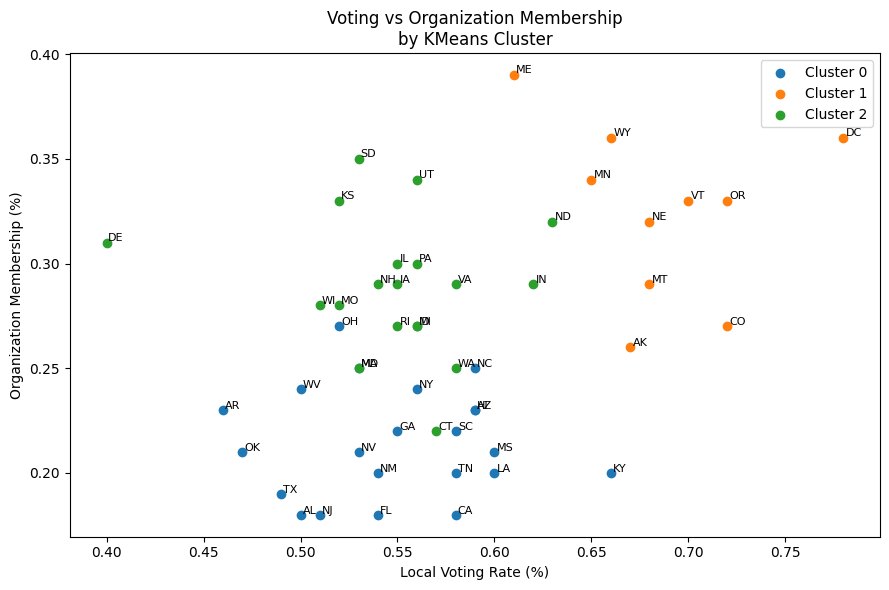

In [147]:
#find columns containing all key words
def find_column(columns, keyword_sets):
    for keywords in keyword_sets:
        for col in columns:
            low = col.lower()
            if all(k in low for k in keywords):
                return col
    return None

cols = list(cev.columns)

voting_keywords = [["vot", "local"], ["local", "vot"], ["local", "vote"], ["local", "voting"]]
org_keywords    = [["org", "member"], ["organiz", "member"], ["organization", "membership"]]

VOTING_COL = find_column(cols, voting_keywords)
ORG_COL    = find_column(cols, org_keywords)

#identify candidate columns for voting and organization
#voting_candidates = (
   #_match_cols(cols, ["vot", "local"]) or
   #_match_cols(cols, ["local", "vot"]) or
   #_match_cols(cols, ["local", "vote"]) or
   #_match_cols(cols, ["local", "voting"])
#)

#org_candidates = (
   #_match_cols(cols, ["org", "member"]) or
   #_match_cols(cols, ["organiz", "member"]) or
   #_match_cols(cols, ["organization", "membership"])
#)

#VOTING_COL = voting_candidates[0]
#ORG_COL    = org_candidates[0]

print(f"Using columns for scatter:\n  Voting = '{VOTING_COL}'\n  Organization = '{ORG_COL}")

plot_df = cev.loc[mask_complete, [label_col, VOTING_COL, ORG_COL]].copy()
plot_df["KMeans3_Z"] = k_labels_z

#scatter plot of Voting vs Organization, colored by KMeans3_Z
plt.figure(figsize=(9, 6))
for c in sorted(plot_df["KMeans3_Z"].unique()):
    sub = plot_df[plot_df["KMeans3_Z"] == c]
    plt.scatter(sub[VOTING_COL], sub[ORG_COL], label=f"Cluster {c}")

#add state labels to points
for _, row in plot_df.iterrows():
    plt.text(row[VOTING_COL]*1.002, row[ORG_COL]*1.002, str(row[label_col]), fontsize=8)

plt.xlabel('Local Voting Rate (%)')
plt.ylabel('Organization Membership (%)')
plt.title("Voting vs Organization Membership\nby KMeans Cluster")
plt.legend()
plt.tight_layout()
plt.show()